# Predicting Communication Drop-off Risk in Dating Apps Using Machine Learning

**Course:** WIA1006/WID3006 Machine Learning  
**Project title:** Predicting Communication Drop-off Risk in Dating Apps Using Machine Learning  
**Group members:** Replace this line with all group member names before submission.

This Google Colab notebook predicts whether an interaction in a synthetic dating-app dataset is likely to end in communication drop-off.

**Target definition:** `dropoff_risk = 1` when `match_outcome` is `Ghosted` or `Chat Ignored`; otherwise `dropoff_risk = 0`.

## Colab Instructions

1. Open this notebook in Google Colab.
2. Upload `dating_app_behavior_dataset.csv` to the Colab session using the file upload panel.
3. Run all cells from top to bottom.
4. Export the completed notebook as `.ipynb` and `.pdf` after the outputs are generated.

The notebook reads `/content/dating_app_behavior_dataset.csv` in Colab. A local fallback path is included only so the notebook can also be checked from this repository.

## 1. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from IPython.display import display, Markdown

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


## 2. Load Dataset

In [ ]:
COLAB_PATH = Path("/content/dating_app_behavior_dataset.csv")
LOCAL_PATH = Path("data/dating_app_behavior_dataset.csv")

data_path = None

if COLAB_PATH.exists():
    data_path = COLAB_PATH
elif LOCAL_PATH.exists():
    data_path = LOCAL_PATH
else:
    try:
        from google.colab import files
        print("Please upload dating_app_behavior_dataset.csv")
        uploaded = files.upload()
        if "dating_app_behavior_dataset.csv" in uploaded:
            data_path = COLAB_PATH
        elif uploaded:
            data_path = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            "Upload dating_app_behavior_dataset.csv to Colab or place it in data/."
        ) from exc

if data_path is None or not data_path.exists():
    raise FileNotFoundError("Could not find the CSV file after upload.")

df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded dataset from: /content/dating_app_behavior_dataset.csv
Dataset shape: 50,000 rows x 19 columns


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


## 3. Dataset Validation and Target Definition

In [ ]:
expected_columns = [
    "gender",
    "sexual_orientation",
    "location_type",
    "income_bracket",
    "education_level",
    "interest_tags",
    "app_usage_time_min",
    "app_usage_time_label",
    "swipe_right_ratio",
    "swipe_right_label",
    "likes_received",
    "mutual_matches",
    "profile_pics_count",
    "bio_length",
    "message_sent_count",
    "emoji_usage_rate",
    "last_active_hour",
    "swipe_time_of_day",
    "match_outcome",
]

missing_columns = sorted(set(expected_columns) - set(df.columns))
extra_columns = sorted(set(df.columns) - set(expected_columns))

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")
if extra_columns:
    print(f"Extra columns found and kept for inspection: {extra_columns}")

if df.shape != (50000, 19):
    print("Warning: expected 50,000 rows and 19 columns based on the assignment description.")

missing_summary = df.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({"missing_values": missing_summary, "dtype": df.dtypes.astype(str)}))

DROPOFF_OUTCOMES = ["Ghosted", "Chat Ignored"]
df["dropoff_risk"] = df["match_outcome"].isin(DROPOFF_OUTCOMES).astype(int)

target_counts = df["dropoff_risk"].value_counts().sort_index()
target_rates = df["dropoff_risk"].value_counts(normalize=True).sort_index()
target_table = pd.DataFrame({"count": target_counts, "rate": target_rates})
target_table.index = ["No drop-off", "Drop-off"]
display(target_table)

assert df.loc[df["match_outcome"].isin(DROPOFF_OUTCOMES), "dropoff_risk"].eq(1).all()
assert df.loc[~df["match_outcome"].isin(DROPOFF_OUTCOMES), "dropoff_risk"].eq(0).all()

print("Target created successfully.")

,missing_values,dtype
gender,0,object
sexual_orientation,0,object
location_type,0,object
income_bracket,0,object
education_level,0,object
interest_tags,0,object
app_usage_time_min,0,int64
app_usage_time_label,0,object
swipe_right_ratio,0,float64
swipe_right_label,0,object


,count,rate
No drop-off,40022,0.80044
Drop-off,9978,0.19956


Target created successfully.


## 4. Exploratory Data Analysis

In [ ]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique(),
})
display(profile)

display(df.describe(include="all").T)

,dtype,missing,unique_values
gender,object,0,6
sexual_orientation,object,0,8
location_type,object,0,6
income_bracket,object,0,7
education_level,object,0,9
interest_tags,object,0,40206
app_usage_time_min,int64,0,301
app_usage_time_label,object,0,7
swipe_right_ratio,float64,0,101
swipe_right_label,object,0,4


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,50000,6,Female,8384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexual_orientation,50000,8,Straight,6326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,50000,6,Remote Area,8519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_bracket,50000,7,High,7309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,50000,9,Bachelor’s,5646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interest_tags,50000,40206,"Fitness, Anime, Yoga",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_usage_time_min,50000.0,NaN,NaN,NaN,149.9124,86.990521,0.0,74.0,150.0,225.0,300.0
app_usage_time_label,50000,7,Extreme User,20140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
swipe_right_ratio,50000.0,NaN,NaN,NaN,0.500655,0.197468,0.0,0.37,0.5,0.64,1.0
swipe_right_label,50000,4,Optimistic,26873,NaN,NaN,NaN,NaN,NaN,NaN,NaN


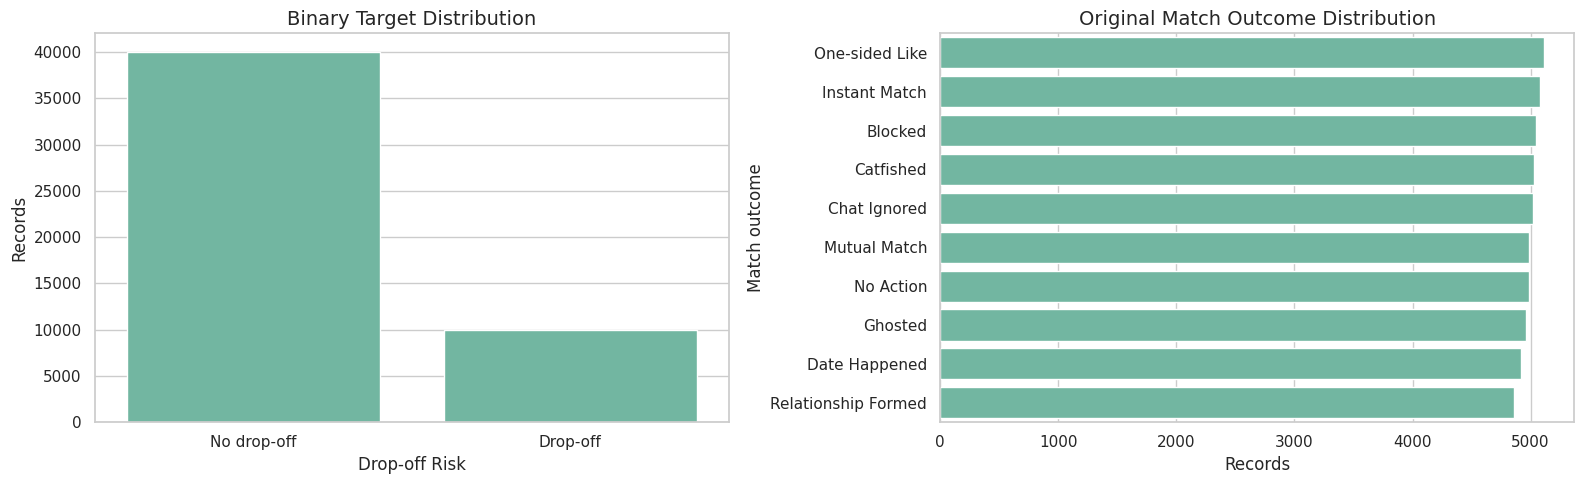

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x="dropoff_risk", ax=axes[0])
axes[0].set_title("Binary Target Distribution")
axes[0].set_xlabel("Drop-off Risk")
axes[0].set_xticklabels(["No drop-off", "Drop-off"])
axes[0].set_ylabel("Records")

outcome_order = df["match_outcome"].value_counts().index
sns.countplot(data=df, y="match_outcome", order=outcome_order, ax=axes[1])
axes[1].set_title("Original Match Outcome Distribution")
axes[1].set_xlabel("Records")
axes[1].set_ylabel("Match outcome")

plt.tight_layout()
plt.show()

,No drop-off mean,Drop-off mean,dropoff_minus_no_dropoff
likes_received,99.417221,99.962518,0.545297
app_usage_time_min,150.006696,149.534175,-0.472521
bio_length,250.111739,250.425737,0.313998
mutual_matches,13.841587,13.985368,0.143781
message_sent_count,50.098446,49.965624,-0.132821
last_active_hour,11.531932,11.481159,-0.050774
profile_pics_count,2.989081,2.982261,-0.006820
emoji_usage_rate,0.286865,0.283560,-0.003305
swipe_right_ratio,0.500237,0.502334,0.002097


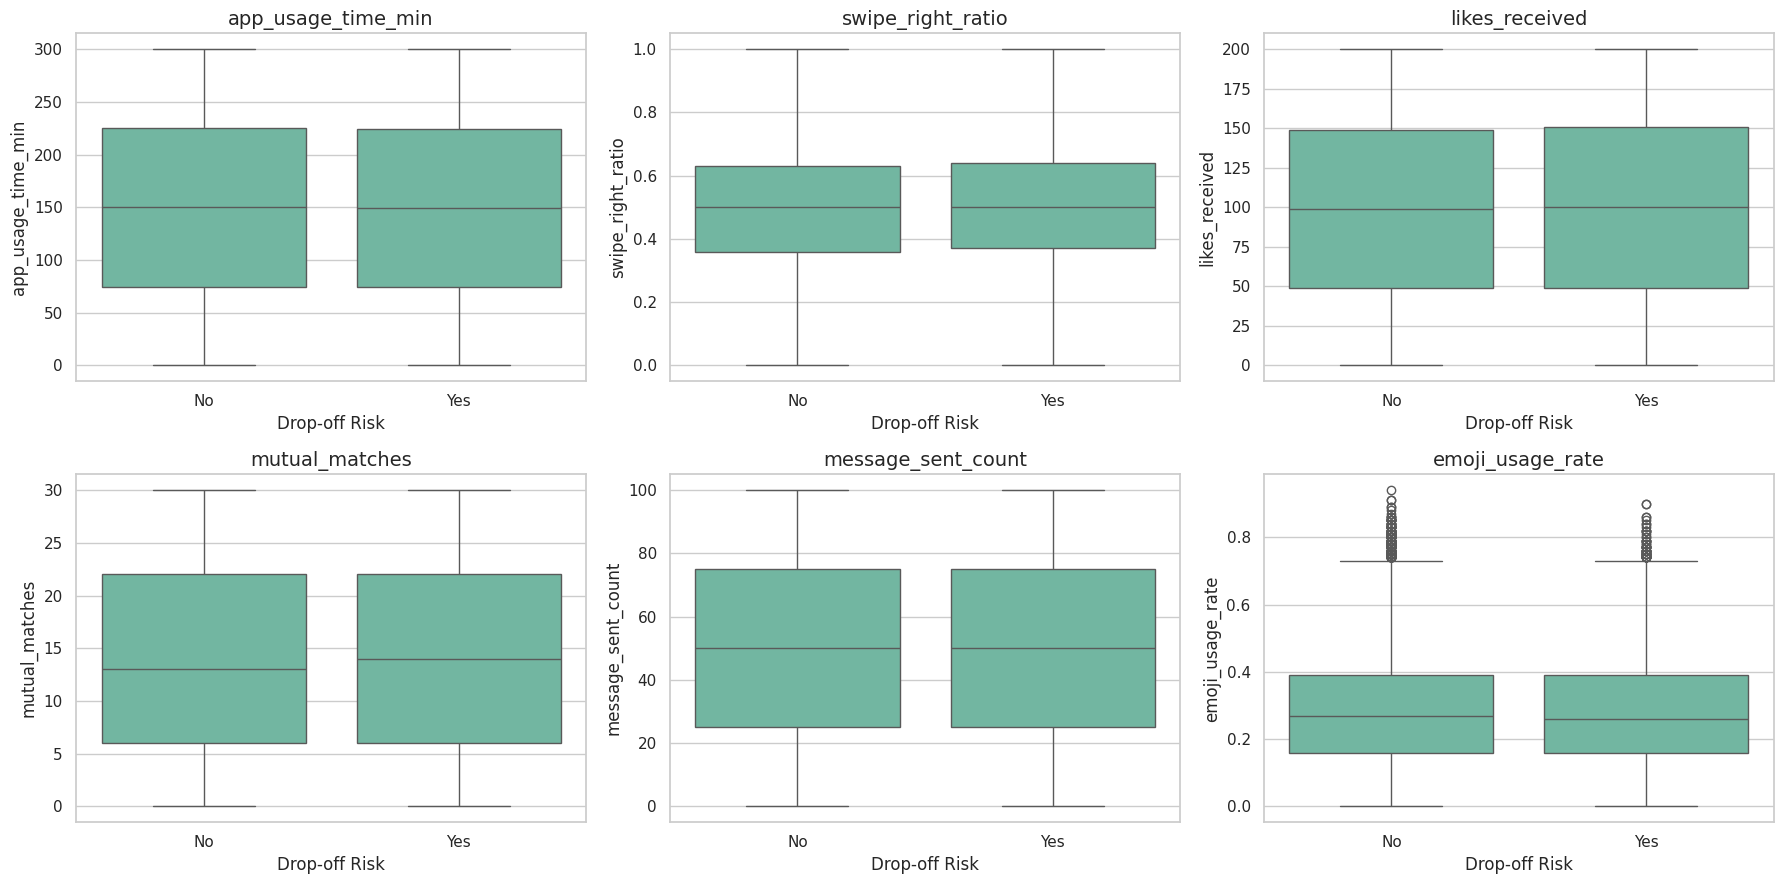

In [ ]:
numeric_cols = [
    "app_usage_time_min",
    "swipe_right_ratio",
    "likes_received",
    "mutual_matches",
    "profile_pics_count",
    "bio_length",
    "message_sent_count",
    "emoji_usage_rate",
    "last_active_hour",
]

group_means = df.groupby("dropoff_risk")[numeric_cols].mean().T
group_means.columns = ["No drop-off mean", "Drop-off mean"]
group_means["dropoff_minus_no_dropoff"] = group_means["Drop-off mean"] - group_means["No drop-off mean"]
display(group_means.sort_values("dropoff_minus_no_dropoff", key=lambda s: s.abs(), ascending=False))

selected_numeric = ["app_usage_time_min", "swipe_right_ratio", "likes_received", "mutual_matches", "message_sent_count", "emoji_usage_rate"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, col in zip(axes, selected_numeric):
    sns.boxplot(data=df, x="dropoff_risk", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Drop-off Risk")
    ax.set_xticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

### Drop-off rate by `app_usage_time_label`

dropoff_risk,No drop-off rate,Drop-off rate
app_usage_time_label,,
Very Low,0.793592,0.206408
High,0.794773,0.205227
Barely,0.798414,0.201586
Low,0.800394,0.199606
Moderate,0.801360,0.198640
Extreme User,0.801589,0.198411
Addicted,0.804622,0.195378


### Drop-off rate by `swipe_right_label`

dropoff_risk,No drop-off rate,Drop-off rate
swipe_right_label,,
Optimistic,0.799018,0.200982
Swipe Maniac,0.799541,0.200459
Balanced,0.803410,0.196590
Choosy,0.803909,0.196091


### Drop-off rate by `location_type`

dropoff_risk,No drop-off rate,Drop-off rate
location_type,,
Metro,0.797902,0.202098
Urban,0.798126,0.201874
Small Town,0.798753,0.201247
Remote Area,0.800329,0.199671
Suburban,0.803158,0.196842
Rural,0.804345,0.195655


### Drop-off rate by `education_level`

dropoff_risk,No drop-off rate,Drop-off rate
education_level,,
Postdoc,0.794628,0.205372
MBA,0.795459,0.204541
Bachelor’s,0.796670,0.203330
Associate’s,0.796690,0.203310
High School,0.797053,0.202947
No Formal Education,0.801401,0.198599
Diploma,0.804480,0.195520
Master’s,0.805742,0.194258
PhD,0.811941,0.188059


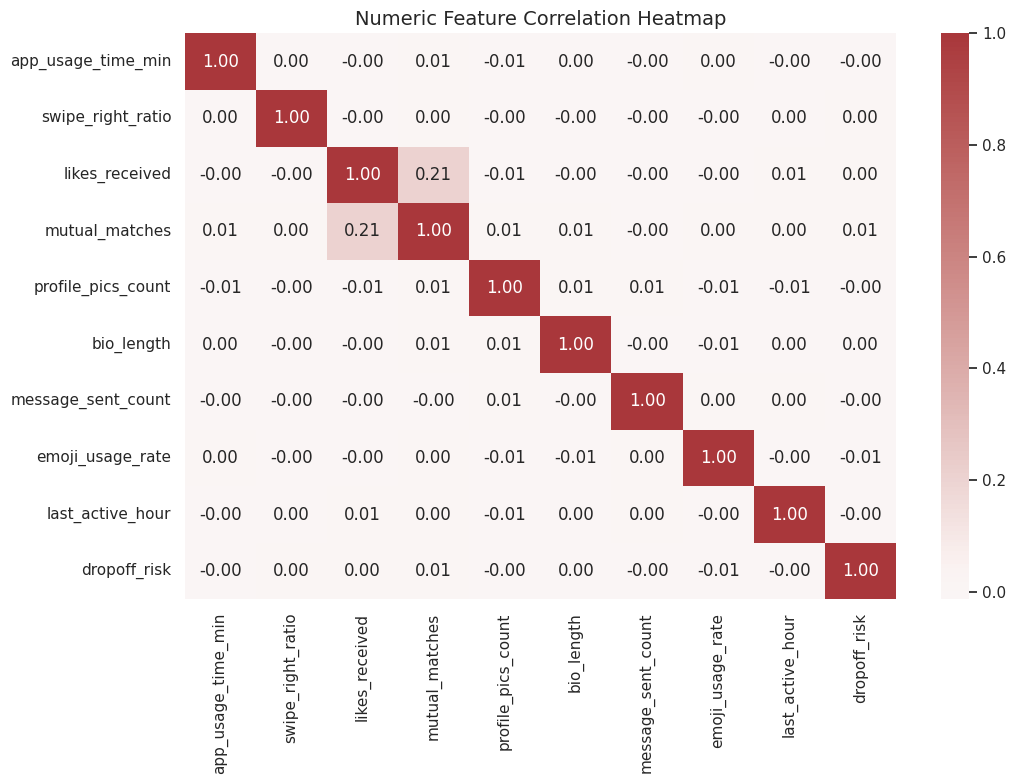

In [ ]:
categorical_cols = [
    "gender",
    "sexual_orientation",
    "location_type",
    "income_bracket",
    "education_level",
    "app_usage_time_label",
    "swipe_right_label",
    "swipe_time_of_day",
]

for col in ["app_usage_time_label", "swipe_right_label", "location_type", "education_level"]:
    rate_table = pd.crosstab(df[col], df["dropoff_risk"], normalize="index")
    rate_table = rate_table.rename(columns={0: "No drop-off rate", 1: "Drop-off rate"})
    display(Markdown(f"### Drop-off rate by `{col}`"))
    display(rate_table.sort_values("Drop-off rate", ascending=False))

corr = df[numeric_cols + ["dropoff_risk"]].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Preprocessing and Train/Test Split

`match_outcome` is removed from the feature matrix after creating `dropoff_risk`, preventing direct target leakage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def split_interest_tags(text):
    if pd.isna(text):
        return []
    return [tag.strip() for tag in str(text).split(",") if tag.strip()]


def build_preprocessor(X_frame):
    numeric_features = X_frame.select_dtypes(include=np.number).columns.tolist()
    categorical_features = [
        col for col in X_frame.select_dtypes(exclude=np.number).columns.tolist()
        if col != "interest_tags"
    ]

    transformers = []

    if numeric_features:
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        transformers.append(("numeric", numeric_pipeline, numeric_features))

    if categorical_features:
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ])
        transformers.append(("categorical", categorical_pipeline, categorical_features))

    if "interest_tags" in X_frame.columns:
        tag_vectorizer = CountVectorizer(
            tokenizer=split_interest_tags,
            token_pattern=None,
            binary=True,
            lowercase=False,
        )
        transformers.append(("interest_tags", tag_vectorizer, "interest_tags"))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0,
    )

    return preprocessor, numeric_features, categorical_features


def build_pipeline(classifier, X_frame):
    preprocessor, _, _ = build_preprocessor(X_frame)
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", classifier),
    ])

In [ ]:
X = df.drop(columns=["match_outcome", "dropoff_risk"])
y = df["dropoff_risk"]

assert "match_outcome" not in X.columns
assert "dropoff_risk" not in X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocessor_preview, numeric_features, categorical_features = build_preprocessor(X_train)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Interest tags encoded with CountVectorizer." )

Train shape: (40000, 18)
Test shape: (10000, 18)
Train positive rate: 0.1996
Test positive rate: 0.1996
Numeric features: ['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour']
Categorical features: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'app_usage_time_label', 'swipe_right_label', 'swipe_time_of_day']
Interest tags encoded with CountVectorizer.


## 6. Model Training and Hyperparameter Tuning

The required models are Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and MLP/ANN. A dummy baseline is included for context but is not counted as one of the five required models.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "Logistic Regression": {
        "classifier": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "classifier__C": [0.1, 1.0, 3.0],
        },
    },
    "Decision Tree": {
        "classifier": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [10, 50],
        },
    },
    "Random Forest": {
        "classifier": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "params": {
            "classifier__n_estimators": [100],
            "classifier__max_depth": [10, None],
            "classifier__min_samples_leaf": [1, 10],
        },
    },
    "Support Vector Machine": {
        "classifier": LinearSVC(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        "params": {
            "classifier__C": [0.1, 1.0, 3.0],
        },
    },
    "MLP / Artificial Neural Network": {
        "classifier": MLPClassifier(
            max_iter=150,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        "params": {
            "classifier__hidden_layer_sizes": [(64,), (64, 32)],
            "classifier__alpha": [0.0001],
        },
    },
}


def fit_grid_model(model_name, classifier, param_grid):
    pipeline = build_pipeline(classifier, X_train)
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    print(f"{model_name} best CV F1: {search.best_score_:.4f}")
    print(f"{model_name} best params: {search.best_params_}")
    return search


fitted_models = {}
search_objects = {}

dummy_model = build_pipeline(DummyClassifier(strategy="most_frequent"), X_train)
dummy_model.fit(X_train, y_train)
fitted_models["Dummy Baseline"] = dummy_model

for model_name, spec in model_specs.items():
    print("=" * 80)
    print(f"Training {model_name}")
    search = fit_grid_model(model_name, spec["classifier"], spec["params"])
    search_objects[model_name] = search
    fitted_models[model_name] = search.best_estimator_

print("All required models have been trained.")

Training Logistic Regression
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Logistic Regression best CV F1: 0.2862
Logistic Regression best params: {'classifier__C': 1.0}
Training Decision Tree
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Decision Tree best CV F1: 0.2755
Decision Tree best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 50}
Training Random Forest
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Random Forest best CV F1: 0.1832
Random Forest best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 100}
Training Support Vector Machine
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Support Vector Machine best CV F1: 0.2862
Support Vector Machine best params: {'classifier__C': 0.1}
Training MLP / Artificial Neural Network
Fitting 3 folds for each of 2 candidates, totalling 6 fits
MLP / Artificial Neural Network best CV F1: 0.0000
MLP / Artificial Neur

## 7. Model Evaluation

In [ ]:
def get_score_values(model, X_eval):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X_eval)[:, 1]
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            return model.decision_function(X_eval)
        except Exception:
            pass
    return None


def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    score_values = get_score_values(model, X_eval)

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
    }

    if score_values is not None and len(np.unique(score_values)) > 1:
        row["roc_auc"] = roc_auc_score(y_eval, score_values)
        row["average_precision"] = average_precision_score(y_eval, score_values)
    else:
        row["roc_auc"] = np.nan
        row["average_precision"] = np.nan

    return row


results = [
    evaluate_model(model_name, model, X_test, y_test)
    for model_name, model in fitted_models.items()
]

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))

required_results_df = results_df[results_df["model"] != "Dummy Baseline"].copy()
best_model_name = required_results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_row = required_results_df.iloc[0]

print(f"Best required model by positive-class F1: {best_model_name}")

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Support Vector Machine,0.5142,0.5077,0.2047,0.4970,0.2900,0.5065,0.2002
1,Logistic Regression,0.5141,0.5077,0.2047,0.4970,0.2899,0.5065,0.2002
2,Decision Tree,0.5240,0.4952,0.1963,0.4474,0.2728,0.4890,0.1939
3,Random Forest,0.6992,0.4966,0.1930,0.1593,0.1745,0.4879,0.1950
4,Dummy Baseline,0.8004,0.5000,0.0000,0.0000,0.0000,nan,nan
5,MLP / Artificial Neural Network,0.8004,0.5000,0.0000,0.0000,0.0000,0.5128,0.2040


Best required model by positive-class F1: Support Vector Machine


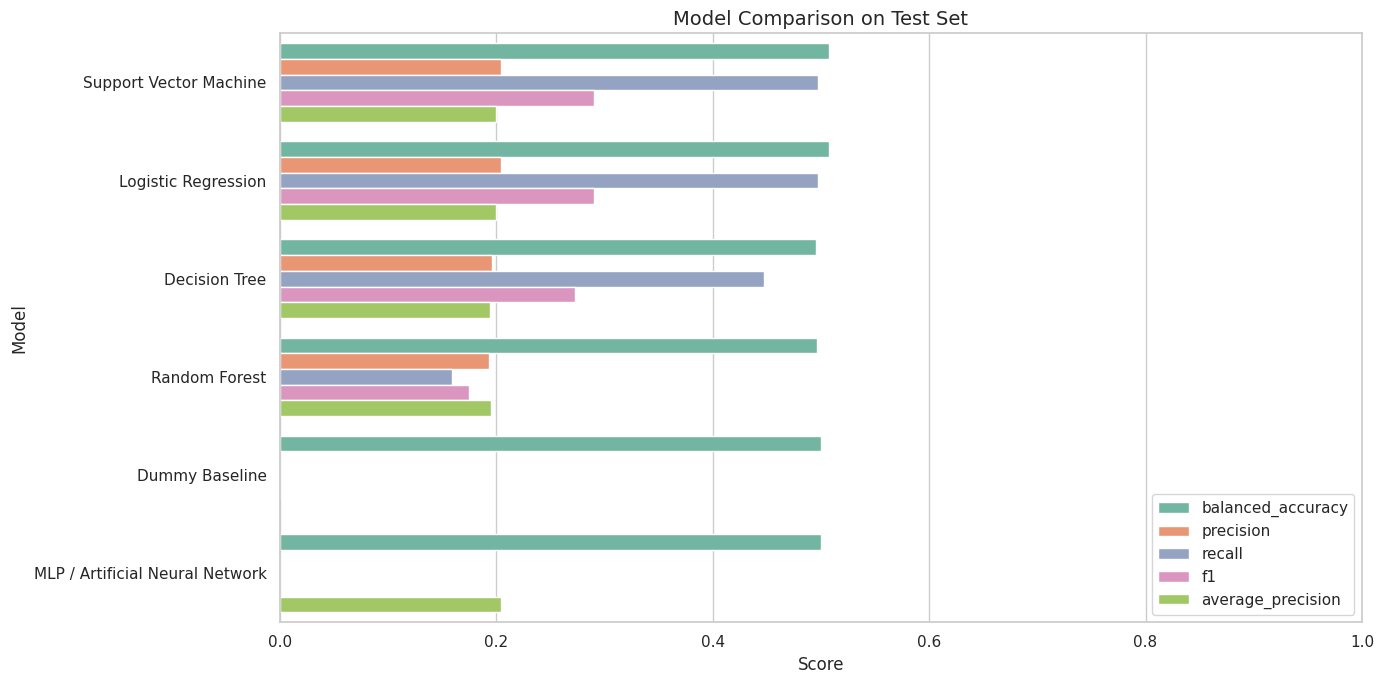

              precision    recall  f1-score   support

 No drop-off       0.81      0.52      0.63      8004
    Drop-off       0.20      0.50      0.29      1996

    accuracy                           0.51     10000
   macro avg       0.50      0.51      0.46     10000
weighted avg       0.69      0.51      0.56     10000



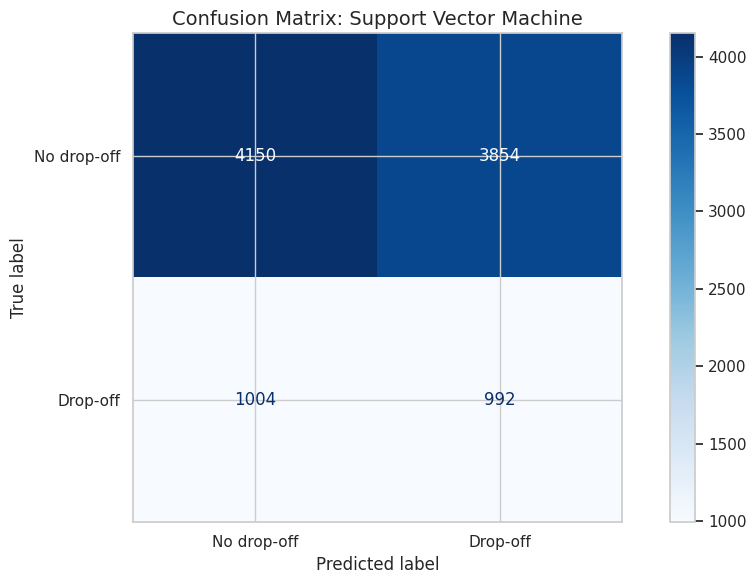

In [ ]:
metric_cols = ["balanced_accuracy", "precision", "recall", "f1", "average_precision"]
plot_df = results_df.melt(id_vars="model", value_vars=metric_cols, var_name="metric", value_name="score")

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="score", y="model", hue="metric")
plt.title("Model Comparison on Test Set")
plt.xlim(0, 1)
plt.xlabel("Score")
plt.ylabel("Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

y_best_pred = best_model.predict(X_test)
print(classification_report(y_test, y_best_pred, target_names=["No drop-off", "Drop-off"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_best_pred,
    display_labels=["No drop-off", "Drop-off"],
    cmap="Blues",
    values_format="d",
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

## 8. Feature Importance and Interpretation

,feature,importance
84,interest_tags__MMA,0.080630
47,categorical__app_usage_time_label_Extreme User,0.073275
80,interest_tags__History,0.069709
51,categorical__app_usage_time_label_Very Low,0.066629
65,interest_tags__Binge-Watching,0.063152
68,interest_tags__Clubbing,0.056432
66,interest_tags__Board Games,0.054145
107,interest_tags__Tech,0.045791
45,categorical__app_usage_time_label_Addicted,0.045393
85,interest_tags__Makeup,0.042268


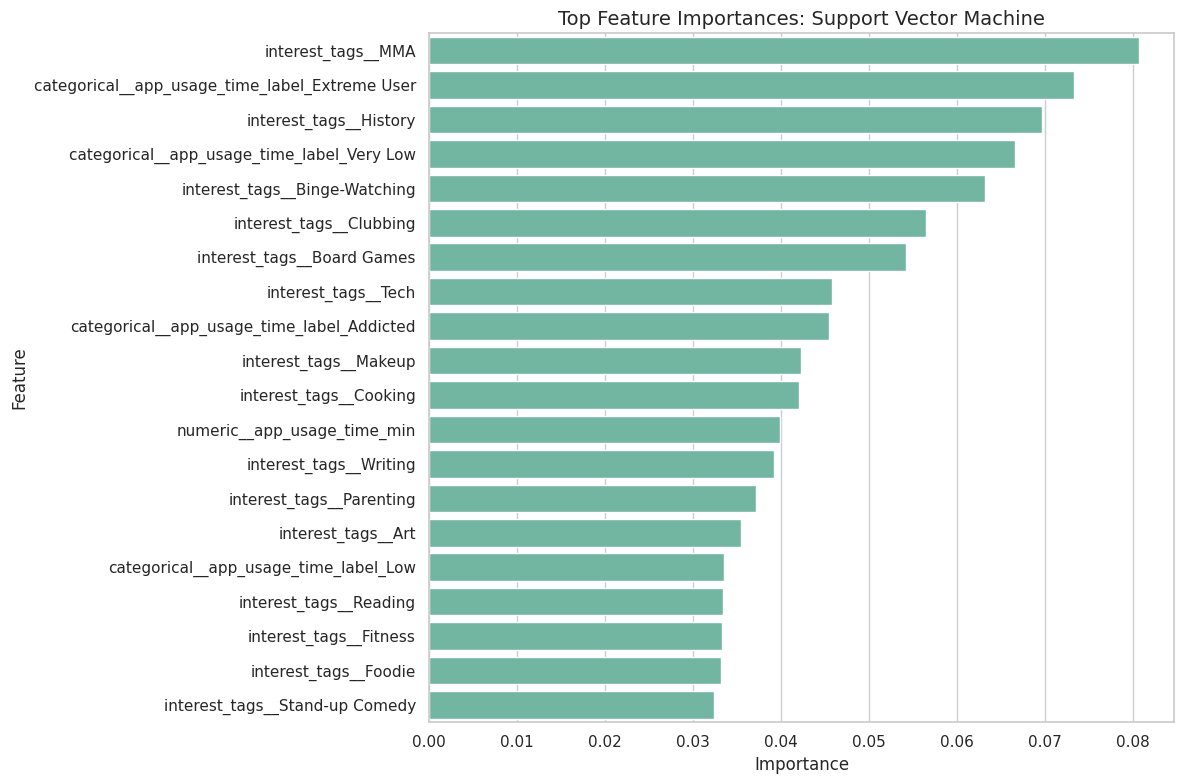

In [ ]:
def get_feature_names_from_pipeline(model):
    try:
        return model.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        return None


feature_names = get_feature_names_from_pipeline(best_model)
classifier = best_model.named_steps["classifier"]

importance_df = None

if feature_names is not None and hasattr(classifier, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_,
    })
elif feature_names is not None and hasattr(classifier, "coef_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(classifier.coef_).ravel(),
    })
else:
    print("The best model does not expose direct coefficients/importances. Computing permutation importance on raw input columns.")
    sample_size = min(2000, len(X_test))
    X_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
    y_sample = y_test.loc[X_sample.index]
    perm = permutation_importance(
        best_model,
        X_sample,
        y_sample,
        scoring="f1",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": X_sample.columns,
        "importance": perm.importances_mean,
    })

importance_df = importance_df.sort_values("importance", ascending=False)
display(importance_df.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.title(f"Top Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 9. Ethics and Sensitive-Feature Ablation

The dataset is synthetic, but the topic still involves sensitive social and demographic variables. This section compares a simple Logistic Regression model with and without selected sensitive columns.

In [ ]:
sensitive_cols = ["gender", "sexual_orientation", "income_bracket"]
available_sensitive_cols = [col for col in sensitive_cols if col in X_train.columns]

ablation_rows = []

for variant_name, drop_cols in {
    "With sensitive columns": [],
    "Without selected sensitive columns": available_sensitive_cols,
}.items():
    X_train_variant = X_train.drop(columns=drop_cols, errors="ignore")
    X_test_variant = X_test.drop(columns=drop_cols, errors="ignore")

    ablation_model = build_pipeline(
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        X_train_variant,
    )
    ablation_model.fit(X_train_variant, y_train)
    row = evaluate_model(variant_name, ablation_model, X_test_variant, y_test)
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))

if "gender" in X_test.columns:
    group_eval = X_test[["gender"]].copy()
    group_eval["y_true"] = y_test.values
    group_eval["y_pred"] = y_best_pred
    gender_metrics = group_eval.groupby("gender").apply(
        lambda g: pd.Series({
            "records": len(g),
            "actual_dropoff_rate": g["y_true"].mean(),
            "predicted_dropoff_rate": g["y_pred"].mean(),
            "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
            "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
        })
    ).sort_values("actual_dropoff_rate", ascending=False)
    display(Markdown("### Group-level check by gender for the best model"))
    display(gender_metrics)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,With sensitive columns,0.5141,0.5077,0.2047,0.4970,0.2899,0.5065,0.2002
1,Without selected sensitive columns,0.5103,0.5046,0.2026,0.4950,0.2875,0.5023,0.1996


### Group-level check by gender for the best model

,records,actual_dropoff_rate,predicted_dropoff_rate,recall,precision
gender,,,,,
Prefer Not to Say,1651.0,0.207147,0.441551,0.429825,0.201646
Non-binary,1633.0,0.205756,0.600122,0.616071,0.211224
Genderfluid,1681.0,0.203450,0.427127,0.438596,0.208914
Transgender,1677.0,0.200954,0.592725,0.614243,0.208249
Male,1690.0,0.192308,0.430769,0.464615,0.207418
Female,1668.0,0.188249,0.417866,0.414013,0.186514


## 10. Optional Auto-sklearn Attempt

The assignment asks for comparison with auto-sklearn. auto-sklearn can be difficult to install in modern hosted notebook environments because it has strict dependency and system requirements. The official installation page states that it requires Linux and does not support Windows due to the Unix-specific `resource` module: https://automl.github.io/auto-sklearn/master/installation.html

This section is disabled by default so the notebook can run top-to-bottom in Colab without spending a long time on environment setup. To attempt auto-sklearn, set `RUN_AUTOSKLEARN = True` and run the cell.

In [ ]:
RUN_AUTOSKLEARN = True

autosklearn_result = {
    "status": "not_run",
    "note": "Set RUN_AUTOSKLEARN = True to attempt installation and training in Colab.",
}

if RUN_AUTOSKLEARN:
    try:
        try:
            import autosklearn.classification
            import autosklearn.metrics
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "auto-sklearn"])
            import autosklearn.classification
            import autosklearn.metrics

        auto_preprocessor, _, _ = build_preprocessor(X_train)
        X_train_auto = auto_preprocessor.fit_transform(X_train)
        X_test_auto = auto_preprocessor.transform(X_test)

        automl = autosklearn.classification.AutoSklearnClassifier(
            time_left_for_this_task=600,
            per_run_time_limit=60,
            metric=autosklearn.metrics.f1,
            seed=RANDOM_STATE,
            n_jobs=-1,
        )
        automl.fit(X_train_auto, y_train)
        y_auto_pred = automl.predict(X_test_auto)

        autosklearn_result = {
            "status": "completed",
            "f1": f1_score(y_test, y_auto_pred, zero_division=0),
            "precision": precision_score(y_test, y_auto_pred, zero_division=0),
            "recall": recall_score(y_test, y_auto_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_auto_pred),
        }
    except Exception as exc:
        autosklearn_result = {
            "status": "failed",
            "error": repr(exc),
            "report_note": (
                "auto-sklearn was attempted but could not be completed in the available Colab environment. "
                "The final report should mention the official system/dependency limitations."
            ),
        }

autosklearn_result

{'status': 'failed',
 'error': "CalledProcessError(1, ['/usr/bin/python3', '-m', 'pip', 'install', 'auto-sklearn'])",
 'report_note': 'auto-sklearn was attempted but could not be completed in the available Colab environment. The final report should mention the official system/dependency limitations.'}

## 11. Report Draft Notes

In [ ]:
display(Markdown(f"""
# Report Notes: Predicting Communication Drop-off Risk in Dating Apps

## Problem and Objective
This project predicts whether a dating-app interaction is likely to end in communication drop-off. The positive class combines `Ghosted` and `Chat Ignored`, because both represent cases where communication does not continue.

## Dataset and Target Definition
- Dataset size: {df.shape[0]:,} rows and {df.shape[1] - 1:,} original columns before adding `dropoff_risk`.
- Positive class count: {int(target_counts.loc[1]):,}.
- Positive class rate: {target_rates.loc[1]:.2%}.

## Methodology
The notebook uses median imputation and standard scaling for numeric features, most-frequent imputation and one-hot encoding for categorical features, and multi-label encoding for comma-separated interest tags. The train/test split is stratified to preserve the drop-off rate.

## Model Comparison
Five required models were trained and tuned: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and MLP/ANN. A dummy baseline was included only for context. The main metric is positive-class F1 score.

## Best Model
- Best required model: **{best_model_name}**
- Test F1: **{best_row['f1']:.4f}**
- Test precision: **{best_row['precision']:.4f}**
- Test recall: **{best_row['recall']:.4f}**
- Test balanced accuracy: **{best_row['balanced_accuracy']:.4f}**

## Auto-sklearn Note
auto-sklearn result status: `{autosklearn_result['status']}`. If it failed or was not run, cite the official installation limitations and explain that the required five manual models remain the core comparison.

## Ethics and Limitations
The dataset is synthetic, so conclusions should not be treated as evidence about real dating-app users. Sensitive demographic attributes can encode bias, so the report should discuss the ablation results and avoid using the model for high-stakes decisions.
"""))


# Report Notes: Predicting Communication Drop-off Risk in Dating Apps

## Problem and Objective
This project predicts whether a dating-app interaction is likely to end in communication drop-off. The positive class combines `Ghosted` and `Chat Ignored`, because both represent cases where communication does not continue.

## Dataset and Target Definition
- Dataset size: 50,000 rows and 19 original columns before adding `dropoff_risk`.
- Positive class count: 9,978.
- Positive class rate: 19.96%.

## Methodology
The notebook uses median imputation and standard scaling for numeric features, most-frequent imputation and one-hot encoding for categorical features, and multi-label encoding for comma-separated interest tags. The train/test split is stratified to preserve the drop-off rate.

## Model Comparison
Five required models were trained and tuned: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and MLP/ANN. A dummy baseline was included only for context. The main metric is positive-class F1 score.

## Best Model
- Best required model: **Support Vector Machine**
- Test F1: **0.2900**
- Test precision: **0.2047**
- Test recall: **0.4970**
- Test balanced accuracy: **0.5077**

## Auto-sklearn Note
auto-sklearn result status: `failed`. If it failed or was not run, cite the official installation limitations and explain that the required five manual models remain the core comparison.

## Ethics and Limitations
The dataset is synthetic, so conclusions should not be treated as evidence about real dating-app users. Sensitive demographic attributes can encode bias, so the report should discuss the ablation results and avoid using the model for high-stakes decisions.


## 12. Slide Outline

Use the results from this notebook to prepare a short presentation:

1. **Title slide**: project title, group member names, course.
2. **Problem**: why communication drop-off is a useful prediction task.
3. **Dataset**: 50,000 synthetic dating-app records, 19 original columns, binary target definition.
4. **EDA findings**: target distribution, outcome distribution, important numeric/categorical patterns.
5. **Methodology**: preprocessing pipeline, stratified split, F1 as main metric.
6. **Models**: Logistic Regression, Decision Tree, Random Forest, SVM, MLP/ANN, plus dummy baseline.
7. **Results**: model comparison chart and best model metrics.
8. **Best model interpretation**: confusion matrix and top feature importance chart.
9. **Ethics and limitations**: synthetic data, sensitive attributes, bias concerns.
10. **Conclusion**: final model choice and what the findings suggest.

## 13. Export Checklist

Before submission:

- Replace the group member placeholder with real names.
- Run the notebook from top to bottom in a fresh Colab runtime after uploading the CSV.
- Confirm the dataset loads as 50,000 rows and 19 original columns.
- Confirm `match_outcome` is not used as a training feature.
- Confirm all five required models produce metrics.
- Save/download the completed `.ipynb`.
- Export or print the completed notebook as `.pdf`.
- Use the report notes and slide outline to prepare the final written report and presentation slides.